# Setup and Libraries

In [1]:
# Cell 0: get current notebook path, its parent, and project root (parent of parent)
import os
from pathlib import Path

# Data manipulation
import pandas as pd
import matplotlib.pyplot as plt

# Visualization
import seaborn as sns

# Optional: improve plots appearance
sns.set(style="whitegrid")

ROOT_DIR = Path(os.getcwd()).resolve().parent


# Load the CSV and json for participants

In [2]:
CSV_PATH = Path("/home/falconnier/Downloads/idaSearch_5_29_2026.csv")
assert CSV_PATH.exists(), f"Dataset directory {CSV_PATH} does not exist."


In [3]:
df = pd.read_csv(CSV_PATH)
print(display(df.head(5)))
print(df.columns)
# print(df["PATNO"].nunique())
# print(df[df["PATNO"] == 3000])

,Subject ID,Project,Phase,Sex,Weight,Research Group,Visit,Archive Date,Study Date,Age,Modality,Description,Imaging Protocol,Image ID
0,002_S_0295,ADNI,ADNI 1,M,74.5,CN,ADNI Screening,4/18/2006,4/18/2006,84.9,MRI,B1-Calibration Body,Acquisition Plane=SAGITTAL;Mfg Model=SIGNA EXC...,13710
1,002_S_0295,ADNI,ADNI 1,M,74.5,CN,ADNI Screening,4/18/2006,4/18/2006,84.9,MRI,B1-Calibration PA,Acquisition Plane=SAGITTAL;Mfg Model=SIGNA EXC...,13711
2,002_S_0295,ADNI,ADNI 1,M,74.5,CN,ADNI Screening,4/18/2006,4/18/2006,84.9,MRI,3-plane localizer,Acquisition Plane=AXIAL;Mfg Model=SIGNA EXCITE...,13712
3,002_S_0295,ADNI,ADNI 1,M,74.5,CN,ADNI Screening,4/18/2006,4/18/2006,84.9,MRI,3-plane localizer,Acquisition Plane=CORONAL;Mfg Model=SIGNA EXCI...,13713
4,002_S_0295,ADNI,ADNI 1,M,74.5,CN,ADNI Screening,4/18/2006,4/18/2006,84.9,MRI,3-plane localizer,Acquisition Plane=SAGITTAL;Mfg Model=SIGNA EXC...,13714


None
Index(['Subject ID', 'Project', 'Phase', 'Sex', 'Weight', 'Research Group',
       'Visit', 'Archive Date', 'Study Date', 'Age', 'Modality', 'Description',
       'Imaging Protocol', 'Image ID'],
      dtype='str')


In [4]:
df["subject"] = df["Subject ID"]  # create a 'subject' column for easier reference
df["age_at_visit"] = df["Age"]
df["session"] = pd.to_datetime(df["Study Date"]).dt.strftime(
    "%Y%m%d"
)  # YYYYMMDD format for session

In [5]:
df.head(5)
print(df[df["subject"] == "002_S_0295"]["session"].unique())

<StringArray>
['20060418', '20061102', '20070525', '20080723', '20090522', '20100513',
 '20110602', '20120510']
Length: 8, dtype: str


Research Group
CN    47540
AD    14322
Name: count, dtype: int64


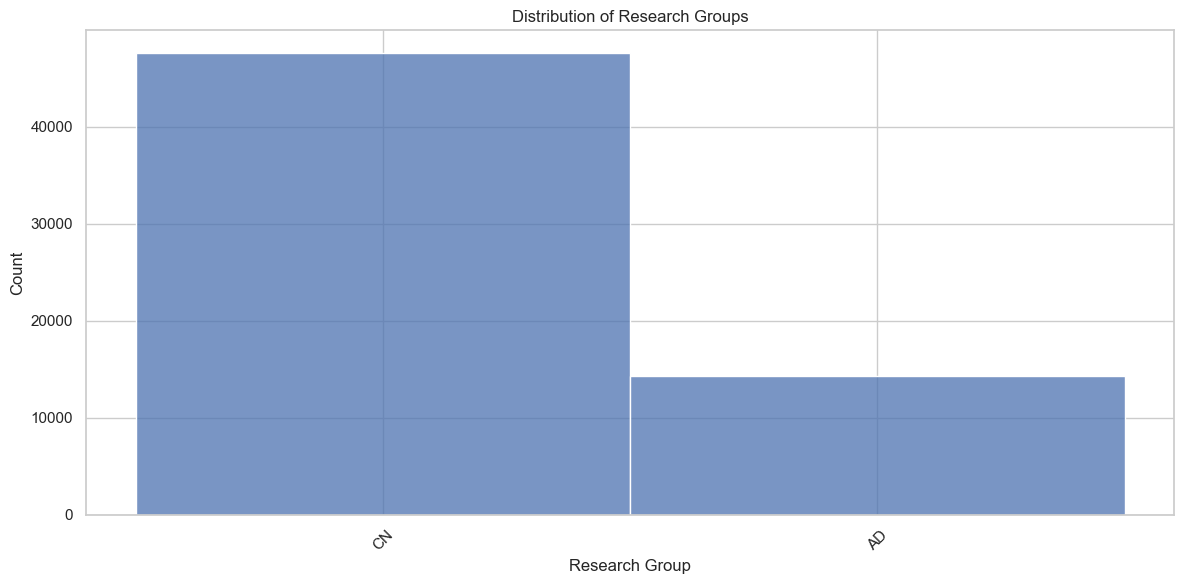

In [6]:
# plot histogran of column "session"
df = df[(df["Research Group"].isin(["CN", "AD"]))].copy()

print(df["Research Group"].value_counts())

plt.figure(figsize=(12, 6))
sns.histplot(df["Research Group"], bins=30, kde=False)
plt.title("Distribution of Research Groups")
plt.xlabel("Research Group")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
df_to_save = df.drop_duplicates(subset=["subject", "session"], keep="first")
assert not df_to_save.duplicated(["subject", "session"]).any()

output_path = CSV_PATH.parent / f"{CSV_PATH.stem}_upgraded.csv"

df_to_save.to_csv(output_path, index=False)
print(f"DataFrame saved to {output_path}")
print(df_to_save[["subject", "session", "age_at_visit"]].head(5))
print(df_to_save[["subject", "session", "age_at_visit"]].head(5).dtypes)

DataFrame saved to /home/falconnier/Downloads/idaSearch_5_29_2026_upgraded.csv
       subject   session  age_at_visit
0   002_S_0295  20060418          84.9
11  002_S_0295  20061102          85.4
20  002_S_0295  20070525          86.0
32  002_S_0295  20080723          87.2
41  002_S_0295  20090522          88.0
subject             str
session             str
age_at_visit    float64
dtype: object
